<a href="https://colab.research.google.com/github/hanyoungin/AIDD-2208-add/blob/main/w2_eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

탐색적 분석 실습
 - 내용 : 타이타닉 승객 정보를 이용하여 탐색적 분석을 수행 하고, 생존자 예측 하기를 모델 생성


1. 패키지 불러오기

In [1]:
from google.colab import drive  #코렙과 구글 드라이브 연동
drive.mount('/content/gdrive',force_remount=True)

Mounted at /content/gdrive


In [2]:
import os

# 예: 'ICT' 폴더로 작업 디렉토리 변경
path = '/content/gdrive/MyDrive/대학원/미래교육원/빅데이터 분석 프로젝트 실무/2주차/'

os.chdir(path)

# 현재 작업 디렉토리 확인
print("현재 경로:", os.getcwd())

현재 경로: /content/gdrive/MyDrive/대학원/미래교육원/빅데이터 분석 프로젝트 실무/2주차


In [3]:
# 연산과 데이터 조작
import numpy as np
import pandas as pd

In [4]:
#시각화
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib

In [5]:
#결측값 시각화
import missingno as msno
plt.style.use('fivethirtyeight')

In [6]:
# Warring 메시지 무시와 현재 창 안에서 시각화
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

In [7]:
# 경로 확인용(테스트) : 아래의 단계로 파일의 경로 확인
import os

# os.listdir 함수는 해당 경로의 존재하는 폴더명(혹은 디렉토리) 출력
os.listdir('./')                      # 출력 : ['.config', 'gdrive', 'sample_data']
os.listdir('./gdrive')                # 출력 : ['.file-revisions-by-id', '.shortcut-targets-by-id', 'MyDrive', '.Trash-0']
os.listdir('./gdrive/MyDrive')        # 출력 : ['data',,,, 등등]
os.listdir('./gdrive/MyDrive/data')   # 출력 : ['train.csv']

FileNotFoundError: [Errno 2] No such file or directory: './gdrive'

2. 데이터 불러오기(구글드라이브 연동)

In [9]:
train_data=pd.read_csv('/content/gdrive/MyDrive/대학원/미래교육원/빅데이터 분석 프로젝트 실무/2주차/train.csv')

3. 데이터 둘러보기


데이터 시각적 확인

In [10]:
train_data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S



•	Survived : 0 = 사망, 1 = 생존   
•	Pclass : 1 = 1등석, 2 = 2등석, 3 = 3등석  
•	Sex : male = 남성, female = 여성  
•	Age : 나이  
•	SibSp : 타이타닉 호에 동승한 자매 / 배우자의 수  
•	Parch : 타이타닉 호에 동승한 부모 / 자식의 수  
•	Ticket : 티켓 번호  
•	Fare : 승객 요금  
•	Cabin : 방 호수  
•	Embarked : 탑승지, C = 셰르부르, Q = 퀸즈타운, S = 사우샘프턴

통계값 확인

In [11]:
train_data.shape

(891, 12)

In [12]:
#데이터 셋의 정보
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [13]:
#데이터의 통계 정보(수자 타입의 통계 정보 생성 가능 칼럼)
train_data.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


컬럼에 비어있는값(Null) 확인

In [14]:
for col in train_data.columns :
    msg = '항목 {:>10}\t 비어있는 자료의 비율 : {:.2f}%'.format(col, 100 * (train_data[col].isnull().sum() / train_data[col].shape[0]))
    print(msg)


항목 PassengerId	 비어있는 자료의 비율 : 0.00%
항목   Survived	 비어있는 자료의 비율 : 0.00%
항목     Pclass	 비어있는 자료의 비율 : 0.00%
항목       Name	 비어있는 자료의 비율 : 0.00%
항목        Sex	 비어있는 자료의 비율 : 0.00%
항목        Age	 비어있는 자료의 비율 : 19.87%
항목      SibSp	 비어있는 자료의 비율 : 0.00%
항목      Parch	 비어있는 자료의 비율 : 0.00%
항목     Ticket	 비어있는 자료의 비율 : 0.00%
항목       Fare	 비어있는 자료의 비율 : 0.00%
항목      Cabin	 비어있는 자료의 비율 : 77.10%
항목   Embarked	 비어있는 자료의 비율 : 0.22%


<Axes: >

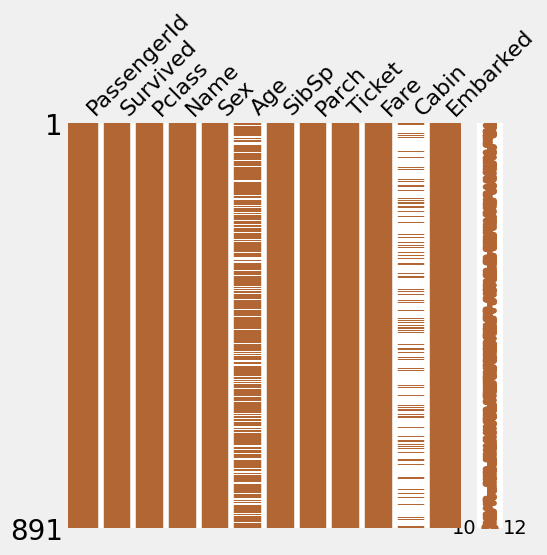

In [15]:
#missingno 이용 시각화
msno.matrix(df=train_data.iloc[:,:], figsize=(5,5), color=(0.7,0.4,0.2))

4. 데이터 탐색적 분석

4.1 사망자 분포 확인

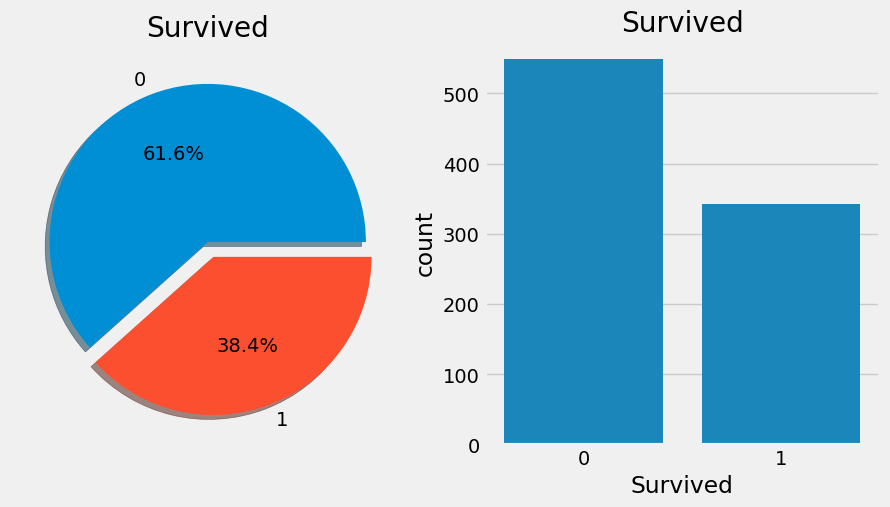

In [16]:
f,ax=plt.subplots(1,2,figsize=(10,5))
train_data['Survived'].value_counts().plot.pie(explode=[0,0.1],autopct='%1.1f%%',ax=ax[0],shadow=True)
ax[0].set_title('Survived')
ax[0].set_ylabel('')
sns.countplot(x='Survived', data=train_data,ax=ax[1])
ax[1].set_title('Survived')
plt.show()


4.2 성별에 따른 사망자와 생존자  
    Sex : male = 남성, female = 여성

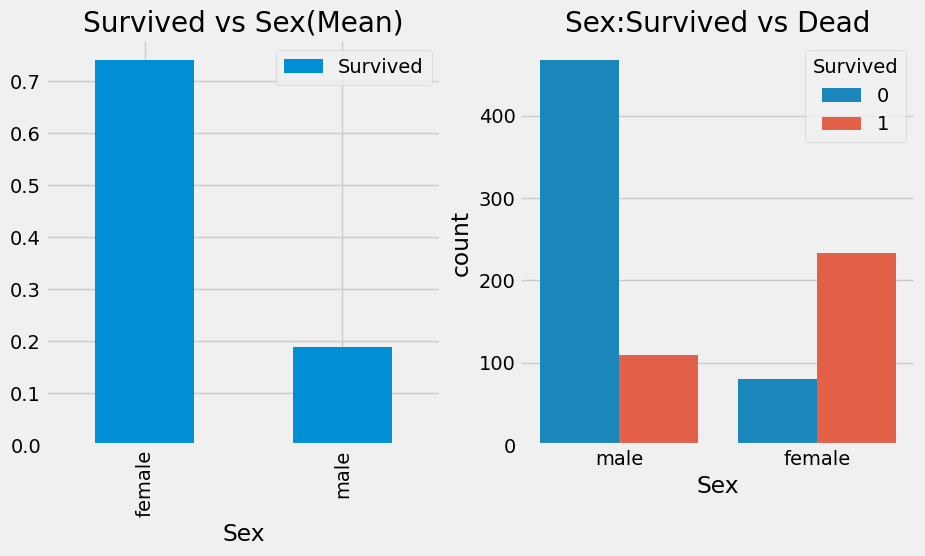

In [17]:
f,ax=plt.subplots(1,2,figsize=(10,5))
train_data[['Sex','Survived']].groupby(['Sex']).mean().plot.bar(ax=ax[0])
ax[0].set_title('Survived vs Sex(Mean)')
sns.countplot(x='Sex',hue='Survived',data=train_data,ax=ax[1])
ax[1].set_title('Sex:Survived vs Dead')
plt.show()

4.3 나이에 따른 사망자와 생존자

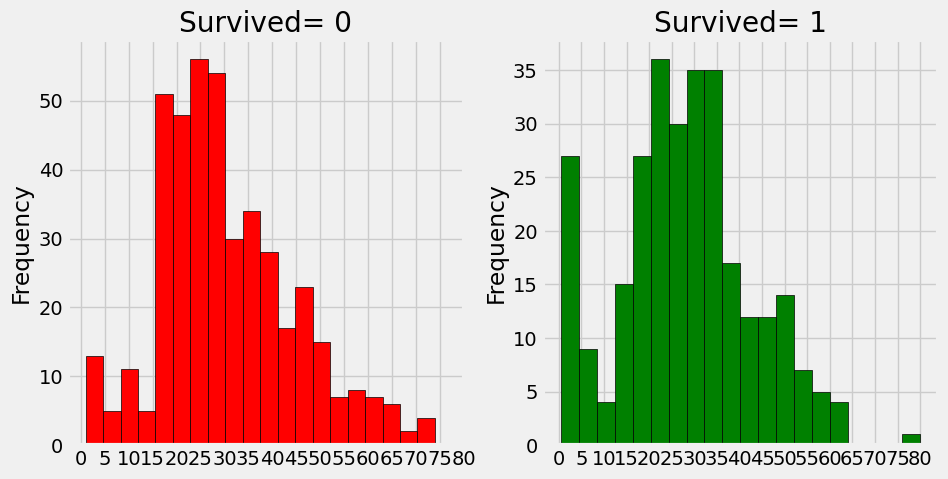

In [18]:
f,ax=plt.subplots(1,2,figsize=(10,5))
train_data[train_data['Survived']==0].Age.plot.hist(ax=ax[0],bins=20,edgecolor='black',color='red')
ax[0].set_title('Survived= 0')
x1=list(range(0,85,5))
ax[0].set_xticks(x1)
train_data[train_data['Survived']==1].Age.plot.hist(ax=ax[1],color='green',bins=20,edgecolor='black')
ax[1].set_title('Survived= 1')
x2=list(range(0,85,5))
ax[1].set_xticks(x2)
plt.show()

직관적 선그래프로 표현

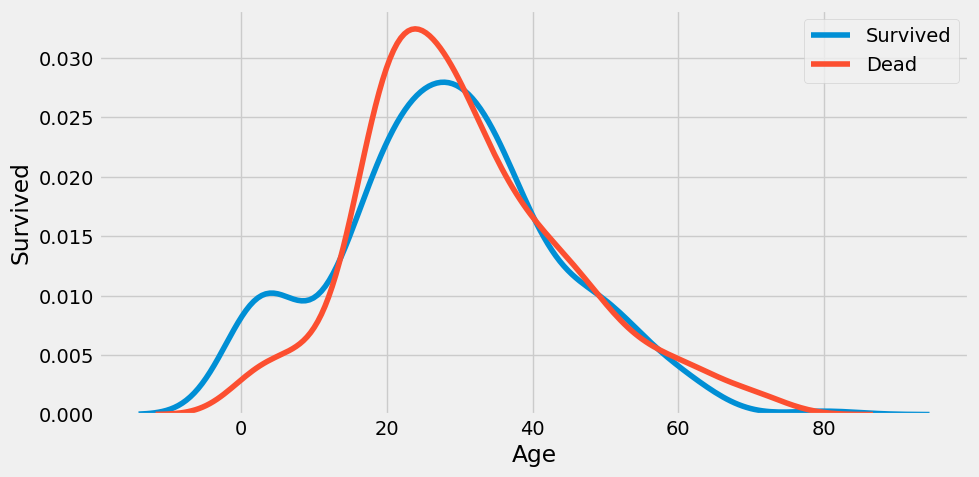

In [19]:
fig, ax = plt.subplots(1,1, figsize=(10,5))
sns.kdeplot(train_data[train_data['Survived'] == 1]['Age'], ax=ax)
sns.kdeplot(train_data[train_data['Survived'] == 0]['Age'], ax=ax)
plt.legend(['Survived','Dead'])
plt.xlabel('Age')
plt.ylabel('Survived')
plt.show()


4.4 클래스에 따른 사망자와 생존자  
• Pclass : 1 = 1등석, 2 = 2등석, 3 = 3등석

In [20]:
pd.crosstab(train_data.Pclass,train_data.Survived,margins=True).style.background_gradient(cmap='summer_r')


Survived,0,1,All
Pclass,,,
1,80,136,216
2,97,87,184
3,372,119,491
All,549,342,891


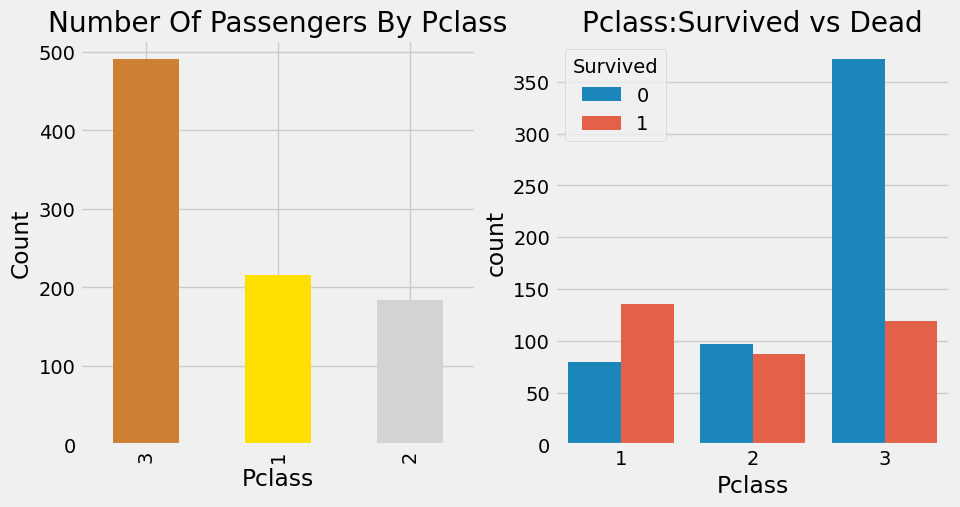

In [21]:
# 좌석 등급별 생존자
f,ax=plt.subplots(1,2,figsize=(10,5))
train_data['Pclass'].value_counts().plot.bar(color=['#CD7F32','#FFDF00','#D3D3D3'],ax=ax[0])
ax[0].set_title('Number Of Passengers By Pclass')
ax[0].set_ylabel('Count')
sns.countplot(x='Pclass',hue='Survived',data=train_data,ax=ax[1])
ax[1].set_title('Pclass:Survived vs Dead')
plt.show()


4.5 클래스별 성별에 따른 사망자와 생존자  
• Sex : male = 남성, female = 여성

In [22]:
pd.crosstab([train_data.Sex, train_data.Survived], train_data.Pclass , margins = True).style.background_gradient(cmap = 'summer_r')

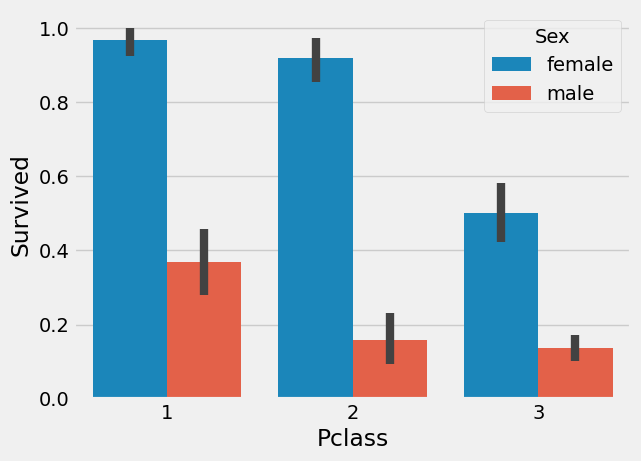

In [23]:
sns.barplot(x='Pclass',y='Survived',hue='Sex',data=train_data)
plt.show()


4.6 탑승장소를 기반으로한 다양한 데이터 조합들  
• Embarked : 탑승지, C = 셰르부르, Q = 퀸즈타운, S = 사우샘프턴

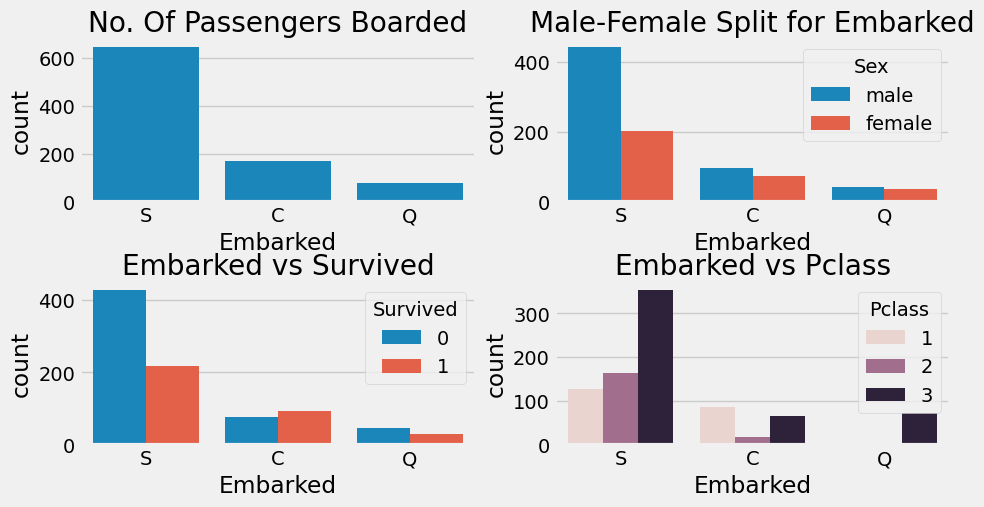

In [24]:
f,ax=plt.subplots(2,2,figsize=(10,5))
sns.countplot(x='Embarked',data=train_data,ax=ax[0,0])
ax[0,0].set_title('No. Of Passengers Boarded')
sns.countplot(x='Embarked',hue='Sex',data=train_data,ax=ax[0,1])
ax[0,1].set_title('Male-Female Split for Embarked')
sns.countplot(x='Embarked',hue='Survived',data=train_data,ax=ax[1,0])
ax[1,0].set_title('Embarked vs Survived')
sns.countplot(x='Embarked',hue='Pclass',data=train_data,ax=ax[1,1])
ax[1,1].set_title('Embarked vs Pclass')
plt.subplots_adjust(wspace=0.2,hspace=0.5)
plt.show()


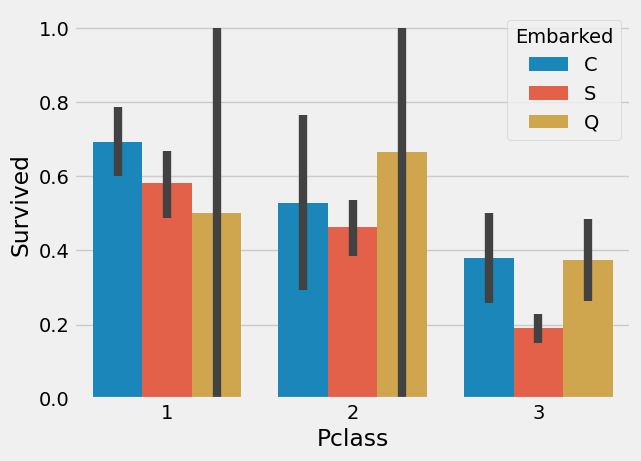

In [25]:
sns.barplot(x='Pclass',y='Survived',hue='Embarked',data=train_data)
plt.show()